# IND320 project 2026
Philip A. K. Øvland \
Github:     https://github.com/Povland/IND320 \
Streamlit:  https://ind320-2026.streamlit.app/\

Video explaining stuff (Please tell me if the link doesn't work):
https://nmbu.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=e331a610-0259-4875-b48e-b4d40146fcb7

## AI Usage

I used AI as a helping hand with: 
    - planning
    - bug fixing
    - making sure I had the correct setup locally
I also used AI for plotting syntax, as the plt-syntax is a headache to remember.

More extensively, AI was use to "auto-complete" things I wrote in VS code. I haven't connected with copilot/etc but still.

## Log
This hand-in was both hard and easy at the same time. The "code" itself wasn't to difficult, but the setup was a headache. \
Control over; Github, Streamlit, Jupyter notebook, uv and all the versions, packages, etc. was a small headache to setup. Not neccesarily to difficult, but still three were loads of small errors. (Especially since I already have loads of projects on the computer.)

### Jupyter notebook
The hand in had a few sections:

    - Reading a file
    - Renaming headers
    - Printing content in a relevant way
    - Plotting each column seperatly
    - Plotting all together (and normalizing them)

Reading a file was pretty simple.\
Renaming headers was also pretty simple\
Printing content was also done pretty straight forward after some "sorting" of the data\
Plotting required some more work than the other stuff. Firstly exclusions of non-numeric data. It also required normalization. Lastly I had to do some other things for the capacity by area (since otherwise it didn't make any sense).

### Streamlit app
The hand in had a few sections:

    - Data import
    - Requrements / uv.lock
    - Page 1: Front-/Homepage with navigation
    - Page 2: Table showing imported data
    - Page 3: Dropdown menu for the data (showing what columns to show) and slider for data to be shown



Reading a file was pretty straight forward. I used what I've allready done here i jupyter in data.py, I also renamed the headers here. I used a decorator (I learned that last year in a june-course).\
Requirements was done with a uv.lock. Not that more to say.\
Page 1 was done pretty easily. Not much to say here.\
Page 2 was more interesting. Here I created a dataframe and showed it on page. Pretty simple in theory, but the places where I had to work was in coming to my current solution.\
Page 3 was the most difficult. Through some trail and error I came to the solution where I had to remove some of the plots and come to my current implementation. 


Written: 29.09.2026




In [73]:
import pandas as pd 
import matplotlib.pyplot as plt

In [74]:
# loads data from csv file
reservoirs = pd.read_csv('data/reservoirs.csv')

In [75]:
# renaming headers
reservoirs.columns = ["date_id", "area_type", "area_nr", "iso_aar", "iso_week", "filling_degree", "capacity_TWh", "filling_TWh", "next_publishing_date", "filling_degree_last_week", "filling_degree_change"]


In [76]:
# Creates a new column with the date_id as datetime and sets it as index. 
#reservoirs.info()
reservoirs["date_id"] = pd.to_datetime(reservoirs["date_id"])
reservoirs = reservoirs.set_index("date_id")

# Sorts the dataframe by index (date_id) in ascending order
reservoirs = reservoirs.sort_index()

# Printing data
reservoirs

,area_type,area_nr,iso_aar,iso_week,filling_degree,capacity_TWh,filling_TWh,next_publishing_date,filling_degree_last_week,filling_degree_change
date_id,,,,,,,,,,
1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
...,...,...,...,...,...,...,...,...,...,...
2026-09-06,EL,4,2026,36,0.902762,21.079208,19.029512,2026-09-16T13:00:00,0.906918,-0.004156
2026-09-06,VASS,1,2026,36,0.570397,36.044464,20.559645,2026-09-16T13:00:00,0.567087,0.003310
2026-09-06,VASS,3,2026,36,0.826252,28.155403,23.263466,2026-09-16T13:00:00,0.827641,-0.001389


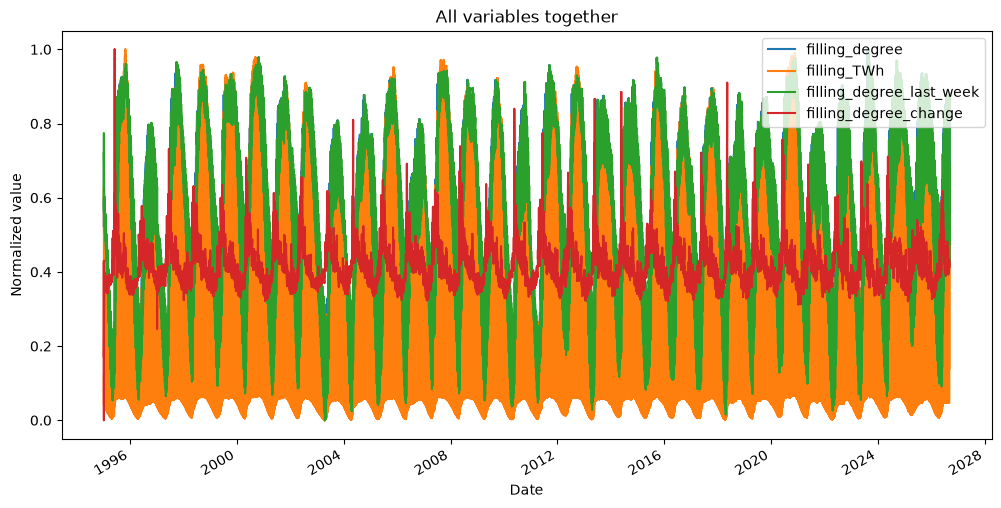

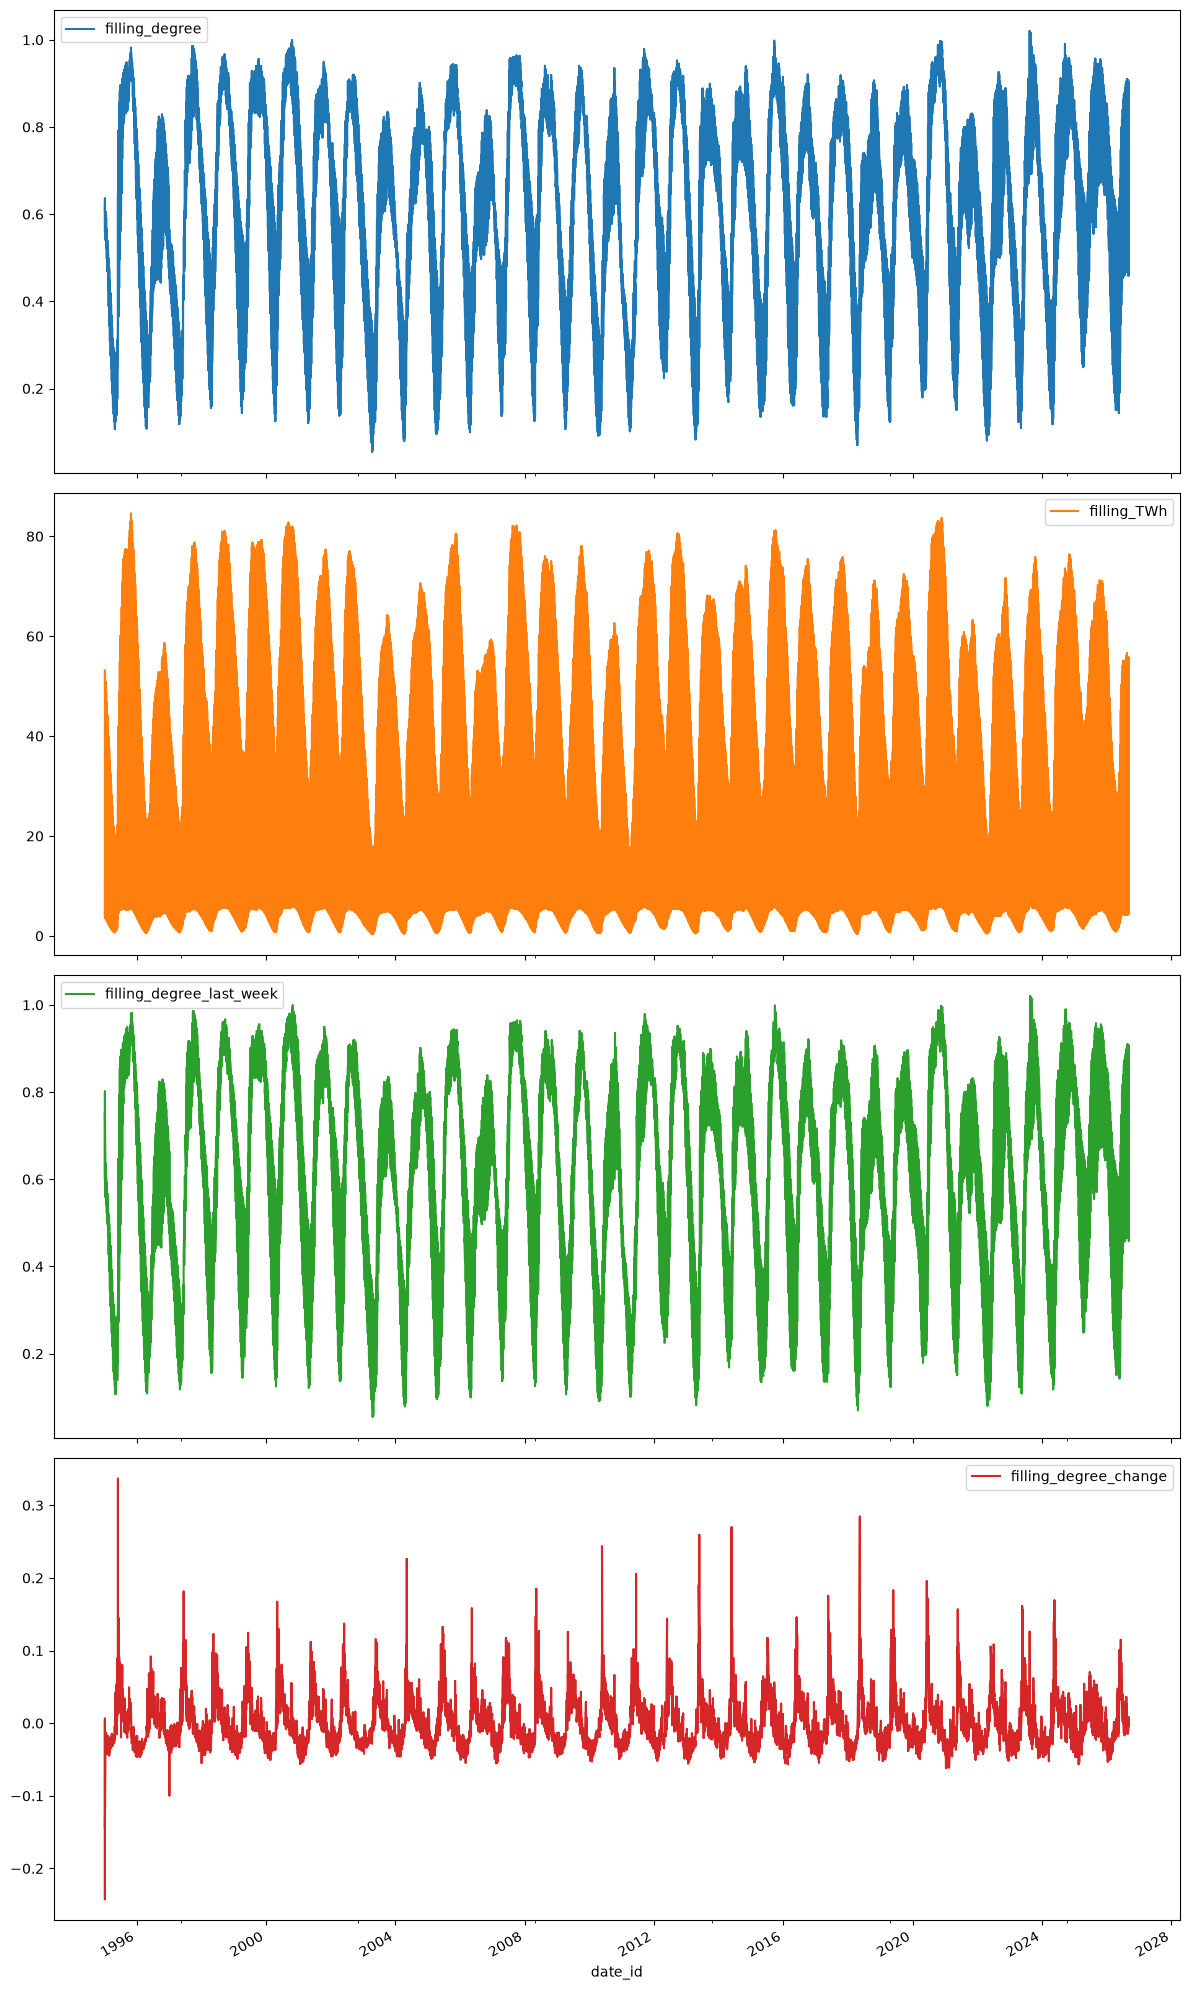

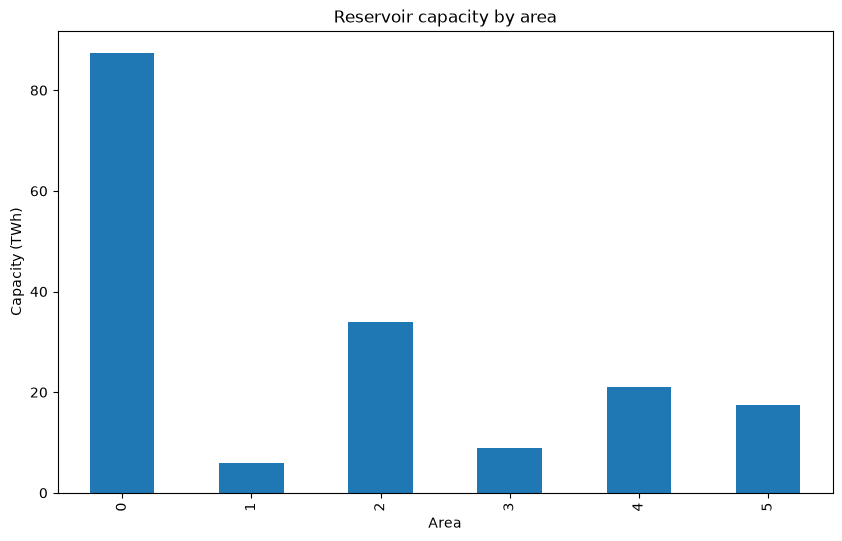

In [77]:
# Not all columns are relevant for plotting, so I select the ones I want to plot
columns_to_plot = [
    "filling_degree",
    "filling_TWh",
    "filling_degree_last_week",
    "filling_degree_change"
]

# Normalizing the data to make it easier to compare the different variables
normalized = reservoirs[columns_to_plot].copy()
normalized = (
    normalized - normalized.min()
) / (
    normalized.max() - normalized.min()
)

normalized.plot(
    figsize=(12, 6)
)

plt.title("All variables together")
plt.xlabel("Date")
plt.ylabel("Normalized value")
plt.legend()
plt.show()
reservoirs[columns_to_plot].plot(
    subplots=True,
    figsize=(12, 20)
)

plt.tight_layout()
plt.show()

# Capacity by area, because capacity (not by area) is constant over time, we can just take the first value for each area
capacity = reservoirs.groupby("area_nr")["capacity_TWh"].first()
capacity.plot(
    kind="bar",
    figsize=(10, 6),
    title="Reservoir capacity by area",
    xlabel="Area",
    ylabel="Capacity (TWh)"
)

plt.show()